# Group 1 stock factor regressions

Apply the six classroom steps to the stocks in stagger_1 only. See `README.md` for methodology and assumptions.

## Run the analysis, then walk through the six classroom steps

The next cell computes the complete pipeline. The walkthrough then examines each stage in order using recorded intermediate standard deviations and coefficients. Foreign stocks follow steps 1 → 2 → 4 → 5 → 6; US stocks follow steps 3 → 4 → 5 → 6. Every comparison uses the same observations before and after the stage for a given stock.

In [ ]:
from pathlib import Path
import sys
import importlib

root = Path.cwd().parent if Path.cwd().name == "group1" else Path.cwd()
sys.path.insert(0, str(root / "group1"))
import stock_factor_regressions

# Refresh the implementation when rerunning in an already-open kernel.
stock_factor_regressions = importlib.reload(stock_factor_regressions)

tables, residuals = stock_factor_regressions.run()

Completed 43 stock/stagger models; results: /Users/josephruocco/QPMFall26/group1/results


## Visual guide to the regression results

Run the cells above first. These charts use the current in-memory `tables` and `residuals` for **stagger_1**. Betas describe sequential, order-dependent regressions; sector betas refer to sector residual factors. They are not coefficients from a single simultaneous regression.

Returns already include the class time weights. Residual standard deviations below are in those weighted four-week return units, not annualized volatility. Selection is exploratory and in-sample.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({"figure.dpi": 110, "font.size": 10, "axes.spines.top": False,
                     "axes.spines.right": False})
plot_stagger = "stagger_1"
plot_diagnostics = (tables["diagnostics"].query("stagger == @plot_stagger")
                    .sort_values(["primary_sector", "ticker"]).set_index("ticker"))
plot_order = plot_diagnostics.index
plot_exposures = (tables["factor_exposures"].query("stagger == @plot_stagger")
                  .set_index("ticker").loc[plot_order])
plot_stages = tables["stage_coefficients"].query("stagger == @plot_stagger")
plot_residuals = residuals[plot_stagger].reindex(columns=plot_order)
plot_labels = [f"{ticker} ({plot_diagnostics.loc[ticker, 'primary_sector']})"
               for ticker in plot_order]

In [ ]:
from IPython.display import display

walk_progress = (tables["residual_progress"].query("stagger == @plot_stagger")
                 .pivot(index="ticker", columns="stage", values="residual_std"))

def show_stage(step, before, after, foreign=None):
    tickers = plot_order
    if foreign is not None:
        mask = plot_diagnostics["currency"].ne("USD")
        tickers = plot_diagnostics.index[mask if foreign else ~mask]
    comparison = walk_progress.loc[tickers, [before, after]].copy()
    comparison.columns = ["Before std", "After std"]
    comparison["Reduction (%)"] = 100 * (1 - comparison["After std"] /
                                        comparison["Before std"].replace(0, np.nan))
    comparison["Observations"] = plot_diagnostics.loc[tickers, "observations"]
    coefficients = plot_stages.loc[plot_stages["step"].eq(step) & plot_stages["ticker"].isin(tickers),
                                  ["ticker", "factor", "beta", "applied_beta", "t_stat", "retained"]]
    display(coefficients.reset_index(drop=True))
    if comparison.empty:
        print("No stocks follow this branch of the workflow.")
        return
    display(comparison.round(4))
    fig, ax = plt.subplots(figsize=(11, max(4, len(tickers) * 0.3)), layout="constrained")
    positions = np.arange(len(tickers))
    ax.barh(positions + 0.18, comparison["Before std"], height=0.36, color="#B8BDC5", label=before)
    ax.barh(positions - 0.18, comparison["After std"], height=0.36, color="#2878A5", label=after)
    ax.set_yticks(positions, tickers, fontsize=8)
    ax.set(title=f"Step {step}: residual variation before and after",
           xlabel="Sample std (weighted four-week return units)")
    ax.legend()
    ax.grid(axis="x", alpha=0.2)
    ax.set_axisbelow(True)
    plt.show()

## Step 1 — Foreign stocks: home-currency exposure

Regress each foreign stock on its home currency with an intercept. Keep the estimated beta and pass the residuals to step 2. US stocks skip this step.

,ticker,factor,beta,applied_beta,t_stat,retained
0,VIST,MXN/USD,0.095817,0.095817,0.186507,True
1,STX,SGD/USD,3.872352,3.872352,2.400987,True
2,NTR,CAD/USD,0.392129,0.392129,1.420435,True
3,ASND,DKK/USD,0.780779,0.780779,1.252609,True
4,NOK,EUR/USD,0.373947,0.373947,0.472577,True


,Before std,After std,Reduction (%),Observations
ticker,,,,
NTR,0.0743,0.0733,1.2688,80
VIST,0.1220,0.1220,0.0223,80
NOK,0.1330,0.1328,0.1429,80
STX,0.1716,0.1656,3.5024,80
ASND,0.1039,0.1029,0.9909,80


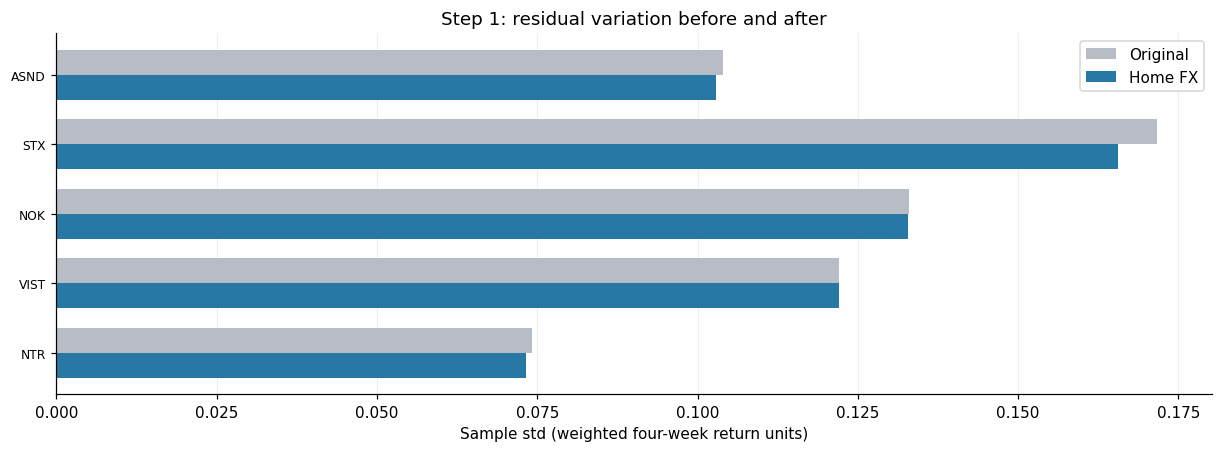

In [ ]:
show_stage(1, 'Original', 'Home FX', foreign=True)

## Step 2 — Foreign stocks: test AUD exposure

Regress the step-1 residuals on AUD/USD. Keep the fitted component only if |t| > 2; otherwise apply beta = 0 and pass the response through unchanged. `beta` is the tested estimate; `applied_beta` records the decision.

,ticker,factor,beta,applied_beta,t_stat,retained
0,VIST,AUD/USD,-0.030131,0.000000,-0.048017,False
1,STX,AUD/USD,1.103577,0.000000,1.309511,False
2,NTR,AUD/USD,1.150948,1.150948,3.252382,True
3,ASND,AUD/USD,0.526408,0.000000,1.000669,False
4,NOK,AUD/USD,0.879685,0.000000,1.301648,False


,Before std,After std,Reduction (%),Observations
ticker,,,,
NTR,0.0733,0.0688,6.1608,80
VIST,0.1220,0.1220,0.0000,80
NOK,0.1328,0.1328,0.0000,80
STX,0.1656,0.1656,0.0000,80
ASND,0.1029,0.1029,0.0000,80


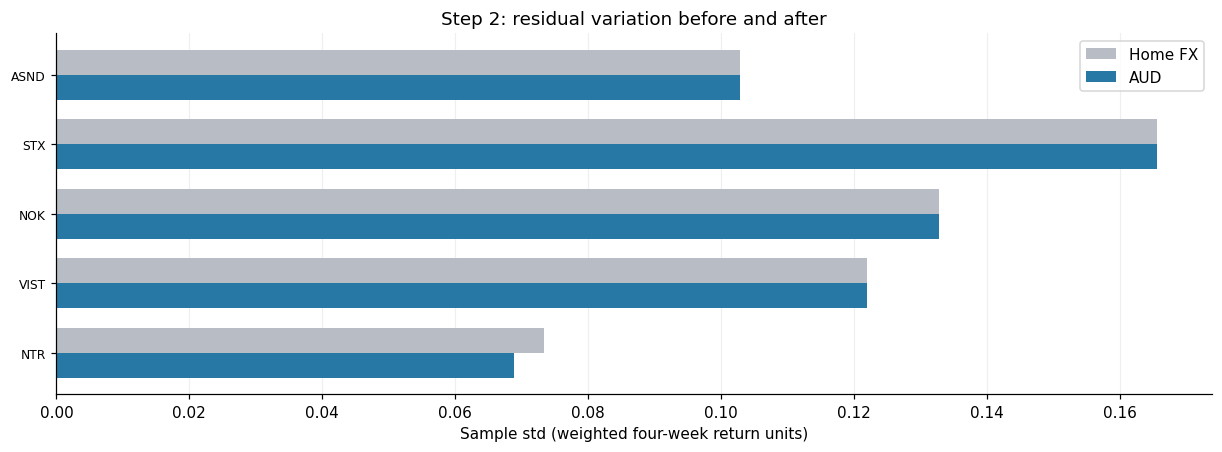

In [ ]:
show_stage(2, 'Home FX', 'AUD', foreign=True)

## Step 3 — US stocks: test AUD exposure

This is the alternative to steps 1–2 for US stocks. Test AUD/USD against the original weighted return using the same strict |t| > 2 rule. Rejected fits leave the response unchanged.

,ticker,factor,beta,applied_beta,t_stat,retained
0,VST,AUD/USD,0.529051,0.000000,0.888333,False
1,AEP,AUD/USD,0.867205,0.867205,3.186870,True
2,ETR,AUD/USD,0.428101,0.000000,1.590126,False
3,DIS,AUD/USD,0.947990,0.947990,2.294841,True
4,CMG,AUD/USD,1.042484,1.042484,2.030972,True
5,AMZN,AUD/USD,0.858462,0.000000,1.858281,False
6,FIX,AUD/USD,1.569809,1.569809,2.708158,True
7,VLO,AUD/USD,0.356318,0.000000,0.631491,False
8,CF,AUD/USD,0.280937,0.000000,0.515313,False
9,LNN,AUD/USD,1.097273,1.097273,3.016177,True


,Before std,After std,Reduction (%),Observations
ticker,,,,
CF,0.1062,0.1062,0.0000,80
NEM,0.1248,0.0989,20.7819,80
CMCSA,0.0711,0.0641,9.8465,80
DIS,0.0830,0.0803,3.2140,80
GOOGL,0.0948,0.0918,3.2063,80
NFLX,0.1147,0.1147,0.0000,80
VLO,0.1100,0.1100,0.0000,80
BRK-B,0.0416,0.0396,4.8713,80
CME,0.0578,0.0558,3.4807,80


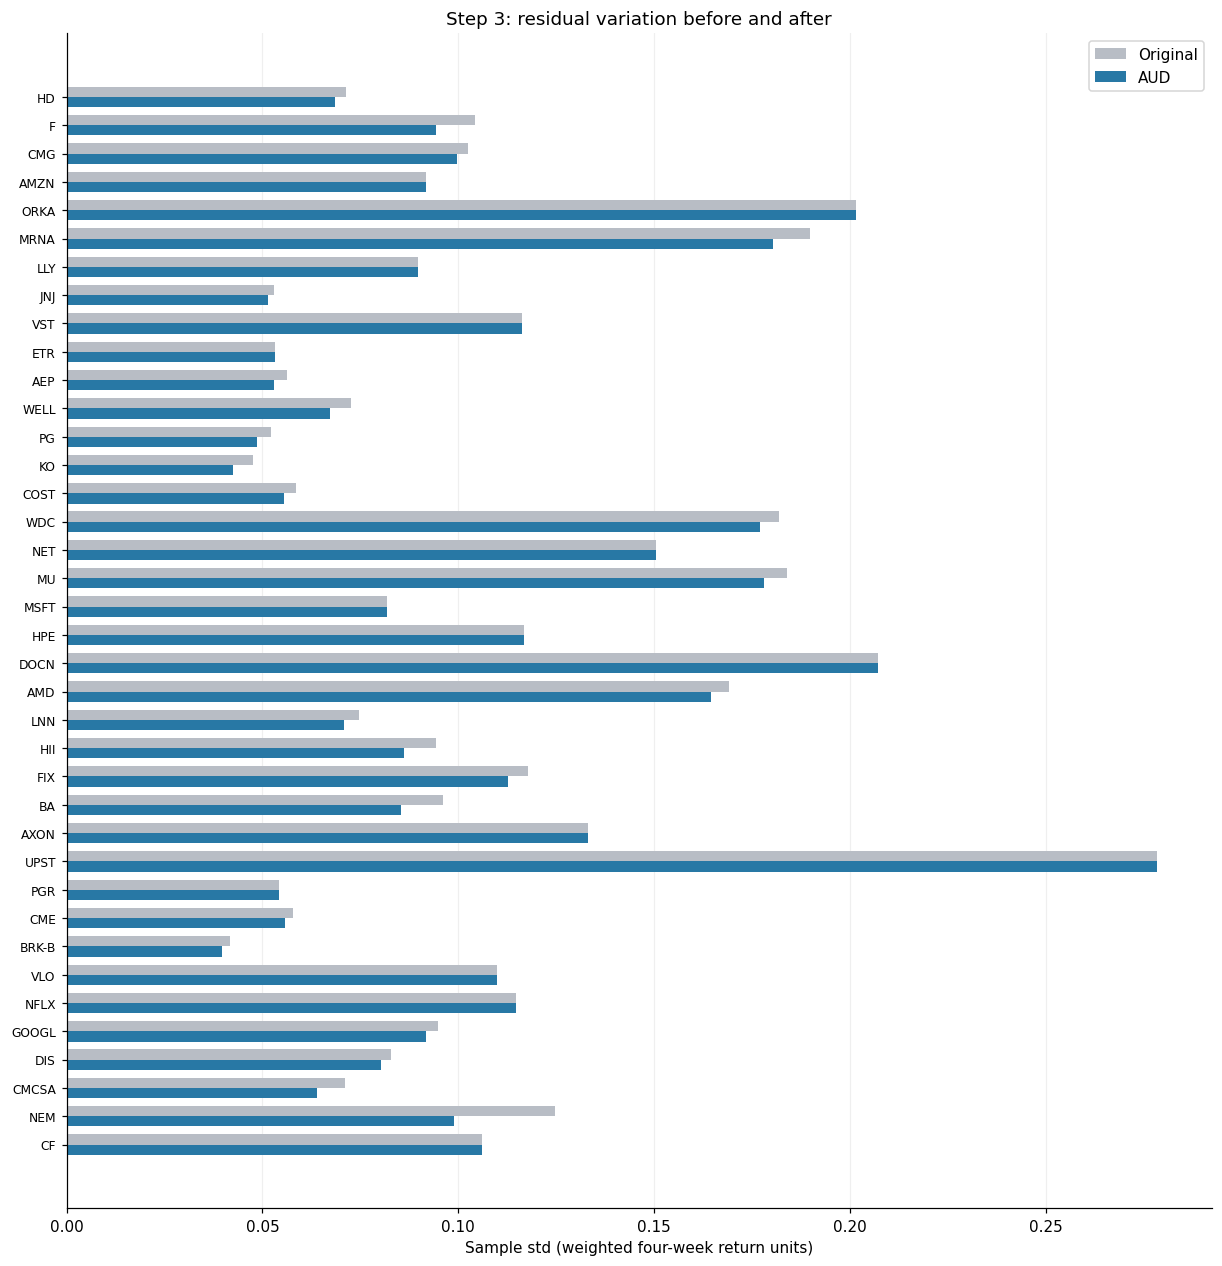

In [ ]:
show_stage(3, 'Original', 'AUD', foreign=False)

## Step 4 — All stocks: remove SPY exposure

Regress the response from the applicable AUD stage on SPY with an intercept. Retain the market beta and pass the residuals forward.

,ticker,factor,beta,applied_beta,t_stat,retained
0,VST,SPY,1.080770,1.080770,3.620642,True
1,VIST,SPY,-0.105156,-0.105156,-0.311101,True
2,AEP,SPY,0.090570,0.090570,0.619042,True
3,ETR,SPY,0.355563,0.355563,2.506846,True
4,DIS,SPY,1.073992,1.073992,5.758416,True
5,CMG,SPY,0.658024,0.658024,2.469751,True
6,AMZN,SPY,1.619583,1.619583,9.182020,True
7,FIX,SPY,1.164377,1.164377,4.110849,True
8,STX,SPY,2.096842,2.096842,5.334886,True
9,VLO,SPY,-0.076133,-0.076133,-0.249801,True


,Before std,After std,Reduction (%),Observations
ticker,,,,
CF,0.1062,0.1038,2.2398,80
NEM,0.0989,0.0988,0.0932,80
NTR,0.0688,0.0676,1.7117,80
CMCSA,0.0641,0.0639,0.3052,80
DIS,0.0803,0.0673,16.2327,80
GOOGL,0.0918,0.0792,13.6809,80
NFLX,0.1147,0.1061,7.4851,80
VIST,0.1220,0.1219,0.0620,80
VLO,0.1100,0.1099,0.0400,80


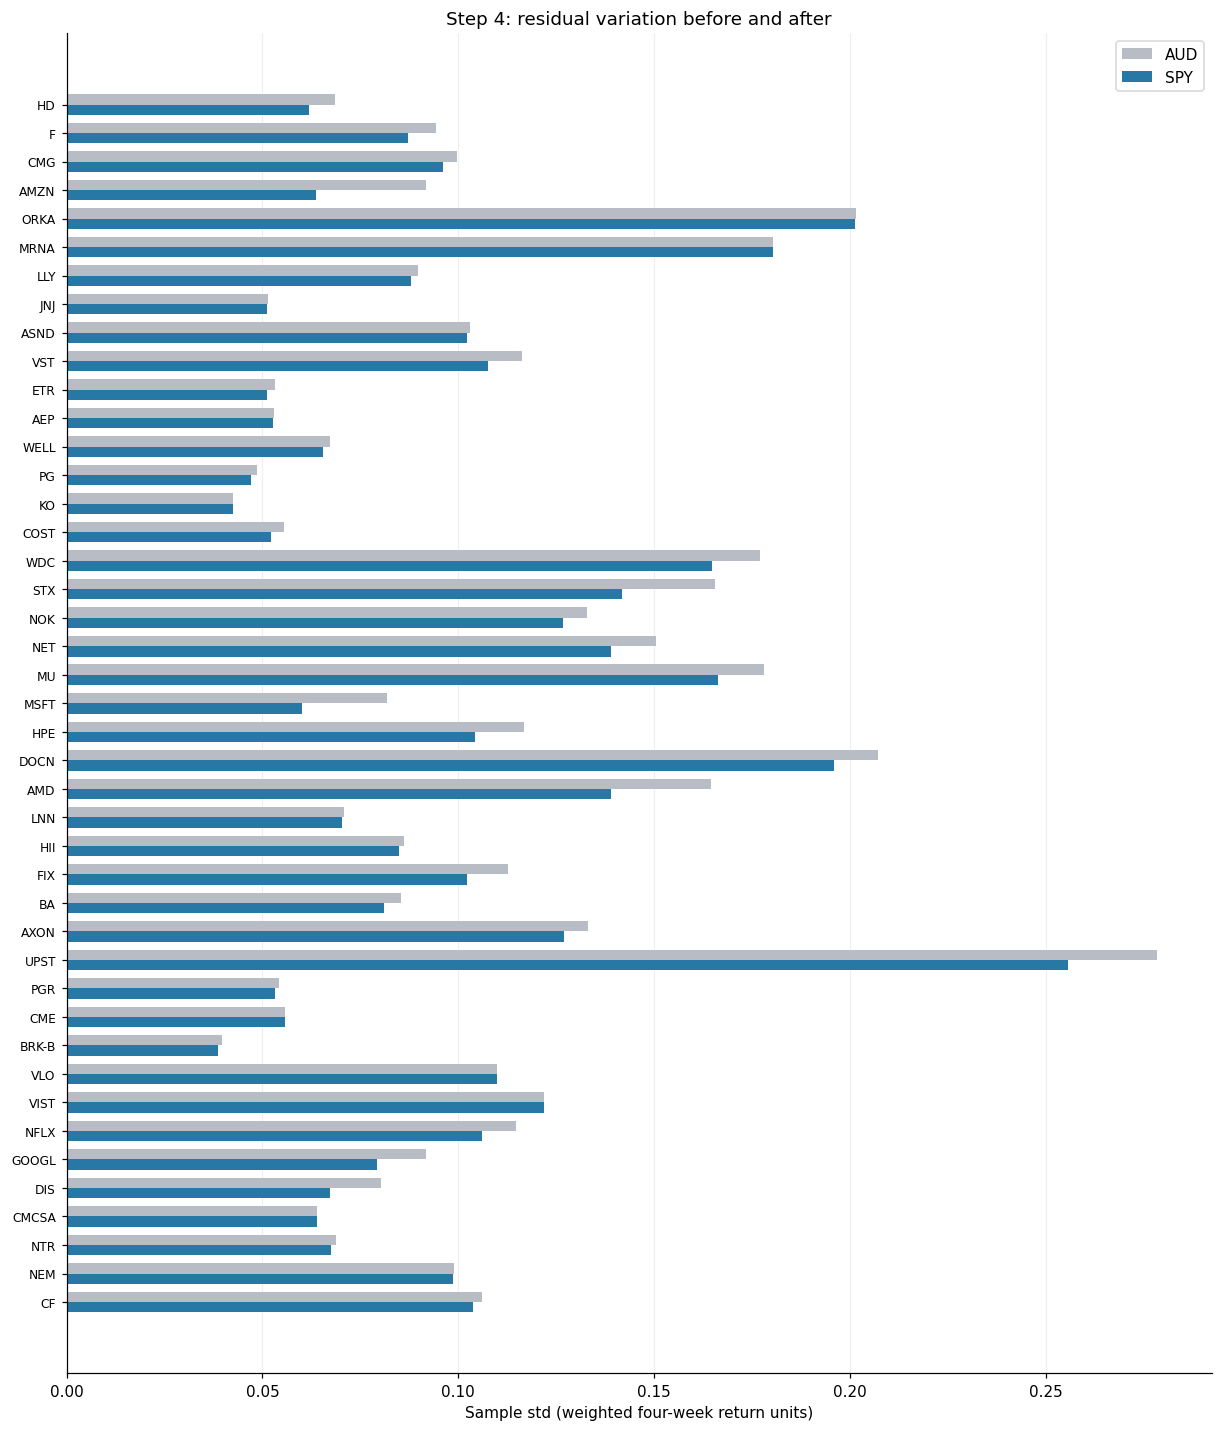

In [ ]:
show_stage(4, 'AUD', 'SPY', foreign=None)

## Step 5 — All stocks: remove the primary sector factor

Regress step-4 residuals on the stock’s primary sector residual factor. Always retain this beta and pass the new residuals forward. Sector factors are already residualized against SPY in the source workbook.

,ticker,factor,beta,applied_beta,t_stat,retained
0,VST,XLU_residual,0.773940,0.773940,2.761090,True
1,VIST,XLE_residual,0.901289,0.901289,5.523379,True
2,AEP,XLU_residual,0.977930,0.977930,10.632750,True
3,ETR,XLU_residual,0.942475,0.942475,10.481544,True
4,DIS,XLC_residual,0.473726,0.473726,1.799483,True
5,CMG,XLY_residual,0.531742,0.531742,1.459201,True
6,AMZN,XLY_residual,1.047856,1.047856,4.901022,True
7,FIX,XLI_residual,0.693957,0.693957,1.759484,True
8,STX,XLK_residual,2.529228,2.529228,6.228180,True
9,VLO,XLE_residual,1.193654,1.193654,10.966479,True


,Before std,After std,Reduction (%),Observations
ticker,,,,
CF,0.1038,0.1016,2.0742,80
NEM,0.0988,0.0969,1.8666,80
NTR,0.0676,0.0653,3.4248,80
CMCSA,0.0639,0.0566,11.3429,80
DIS,0.0673,0.0659,2.0133,80
GOOGL,0.0792,0.0767,3.1423,80
NFLX,0.1061,0.1014,4.5009,80
VIST,0.1219,0.1034,15.2154,80
VLO,0.1099,0.0689,37.2772,80


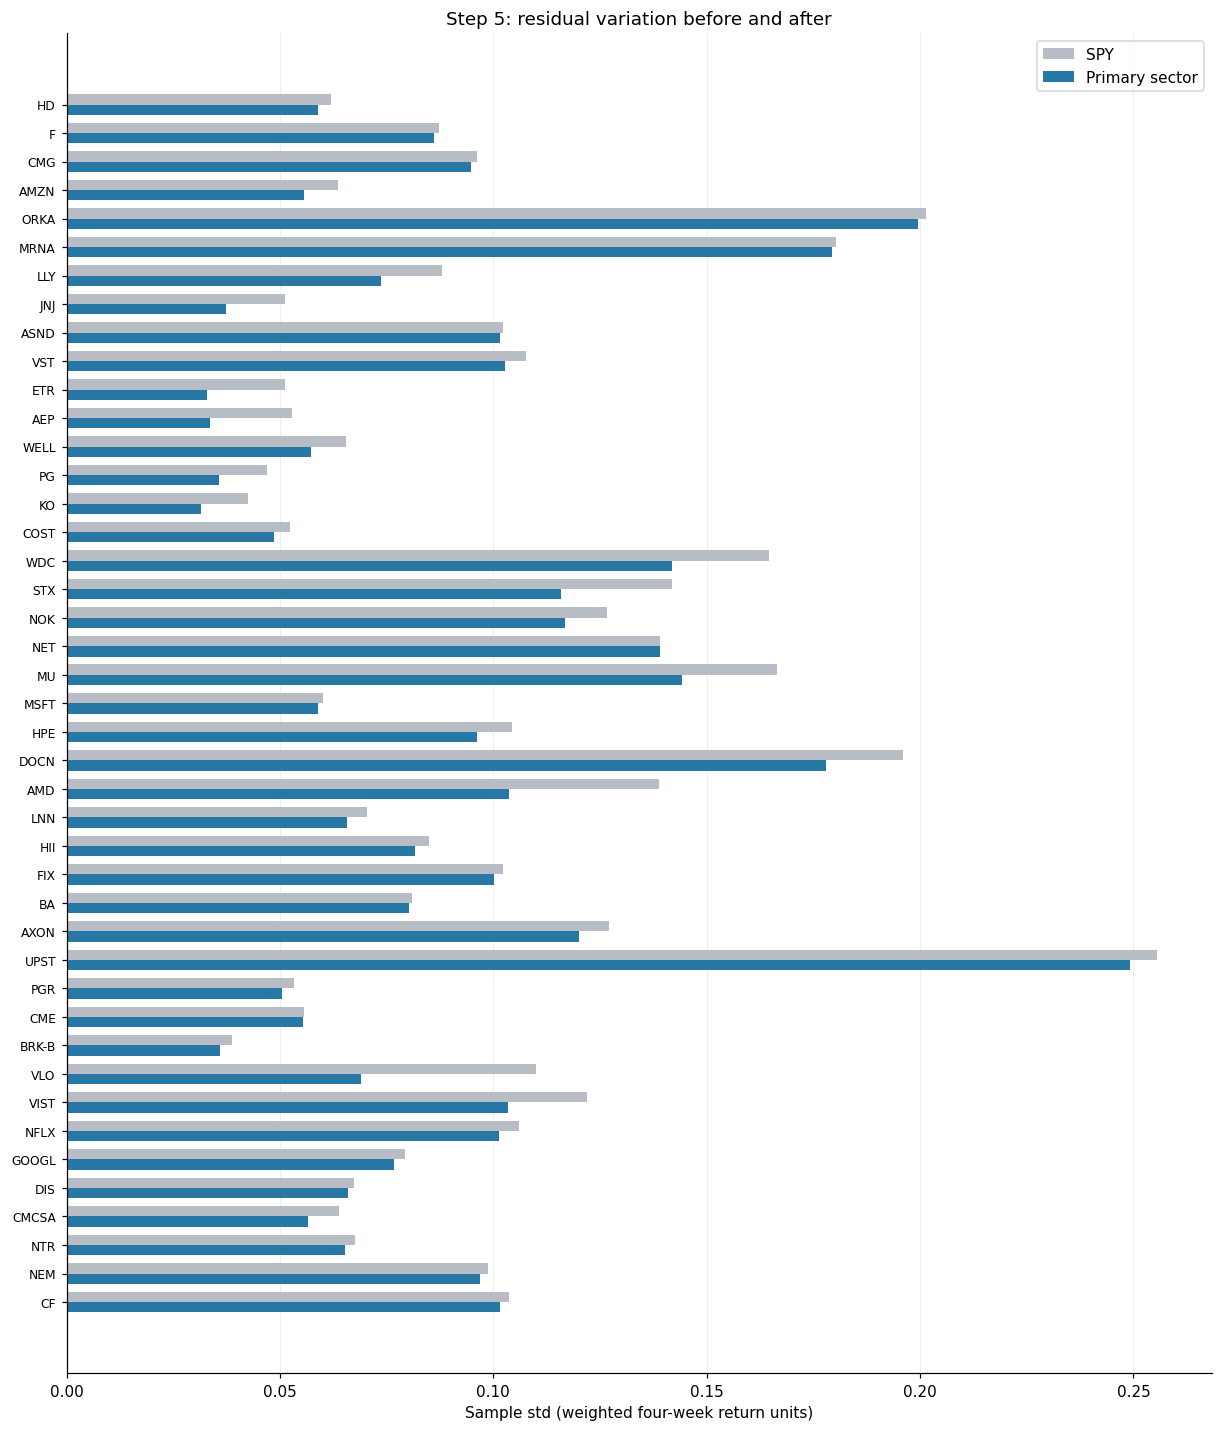

In [ ]:
show_stage(5, 'SPY', 'Primary sector', foreign=None)

## Step 6 — All stocks: select additional sector factors

Forward-select remaining sector residual factors against the fixed step-5 response. Each addition must leave every selected coefficient at |t| > 2 in the joint refit. The coefficient table shows the final retained set; stocks with no qualifying additions stay unchanged. The chart compares step 5 with the final joint fit.

,ticker,factor,beta,applied_beta,t_stat,retained
0,VST,XLV_residual,-1.006887,-1.006887,-3.228181,True
1,VIST,XLV_residual,-0.850885,-0.850885,-2.660257,True
2,AEP,XLRE_residual,0.313767,0.313767,2.802445,True
3,AEP,XLB_residual,-0.227449,-0.227449,-2.227525,True
4,DIS,XLV_residual,-0.643158,-0.643158,-3.158896,True
5,DIS,XLF_residual,0.558949,0.558949,2.373417,True
6,CMG,XLE_residual,-0.324756,-0.324756,-2.238342,True
7,AMZN,XLB_residual,-0.677576,-0.677576,-4.802518,True
8,AMZN,XLV_residual,-0.314798,-0.314798,-2.017928,True
9,FIX,XLRE_residual,-0.890692,-0.890692,-2.997047,True


,Before std,After std,Reduction (%),Observations
ticker,,,,
CF,0.1016,0.0814,19.8841,80
NEM,0.0969,0.0969,0.0000,80
NTR,0.0653,0.0627,4.0018,80
CMCSA,0.0566,0.0517,8.7211,80
DIS,0.0659,0.0610,7.4518,80
GOOGL,0.0767,0.0629,18.0053,80
NFLX,0.1014,0.0946,6.6248,80
VIST,0.1034,0.0990,4.2494,80
VLO,0.0689,0.0689,0.0000,80


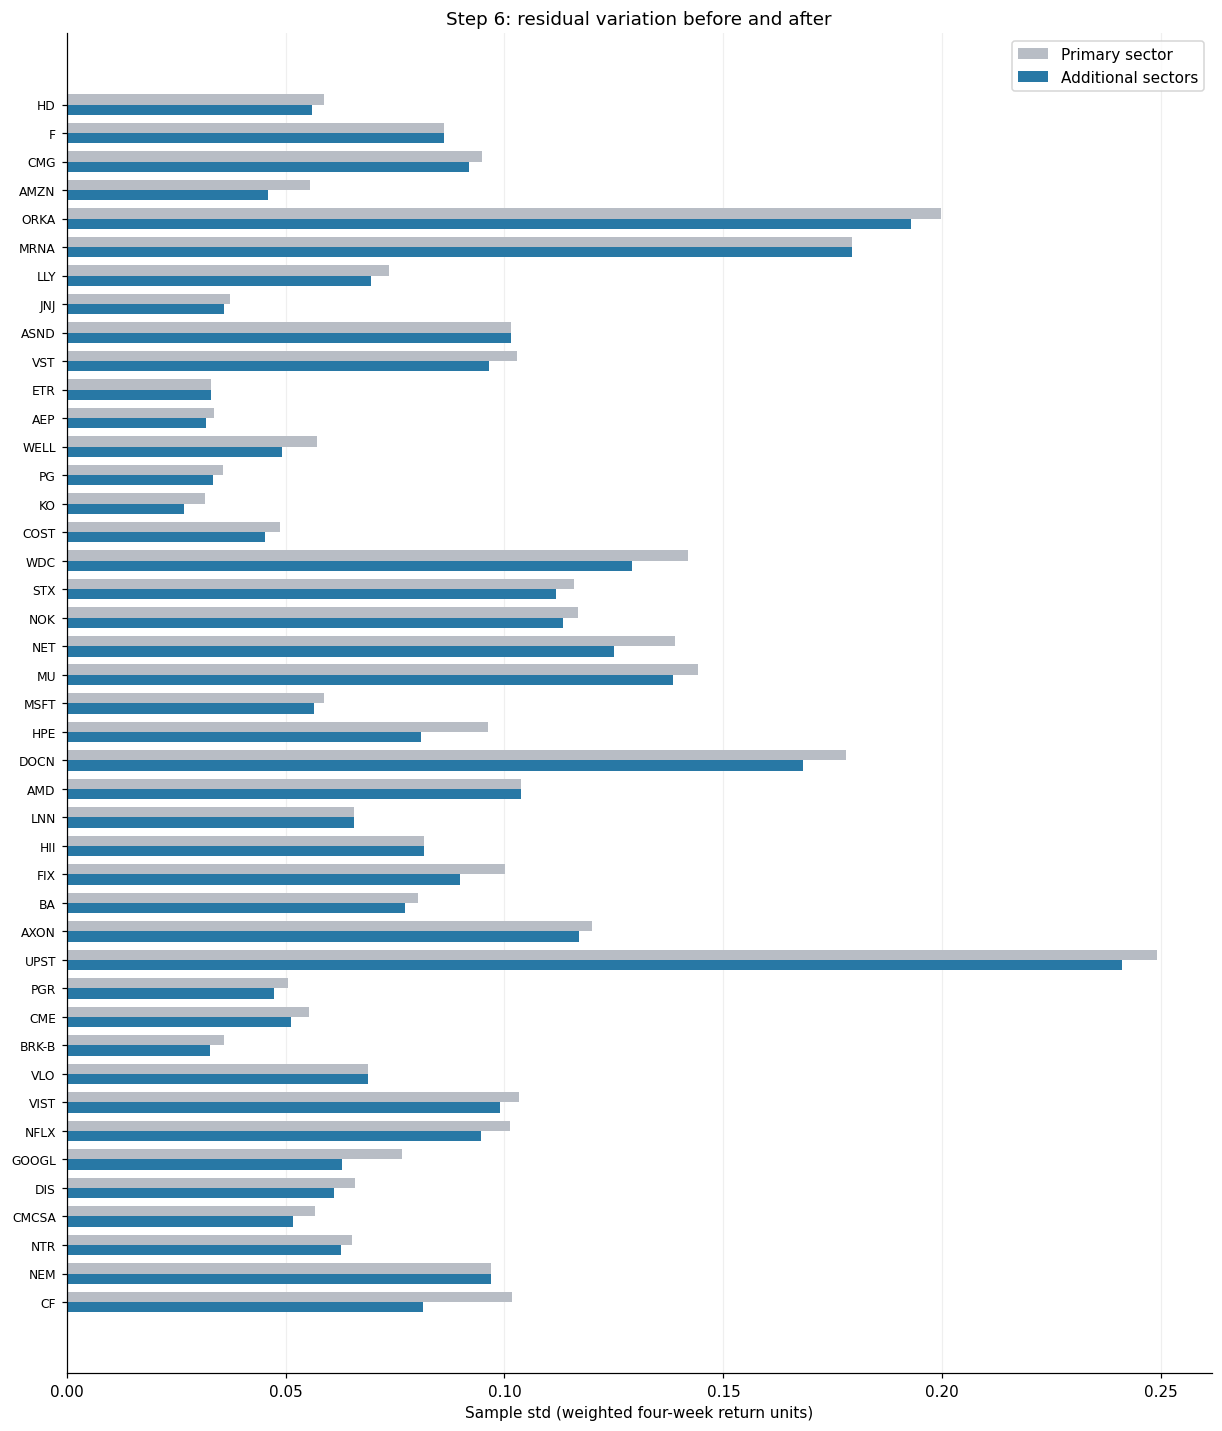

In [ ]:
show_stage(6, 'Primary sector', 'Additional sectors', foreign=None)

### Are residuals getting smaller at each stage?

Each line tracks one stock on its fixed complete-case sample. Standard deviations are normalized to that stock's original standard deviation: 1 means no reduction, 0.5 means half the original variation. Retained OLS stages with an intercept cannot increase sample residual variance, apart from numerical tolerance; skipped stages stay flat. The additional-sector point summarizes the final joint fit, not every candidate search iteration.

The heatmap shows the **percentage reduction in standard deviation relative to the preceding stage**. Zero can mean a skipped stage or negligible improvement. This is an in-sample fit check, not evidence of out-of-sample predictive power. The table reports any increases exceeding numerical tolerance.

Checked 43 stocks across 5 transitions: 0 increases beyond numerical tolerance.


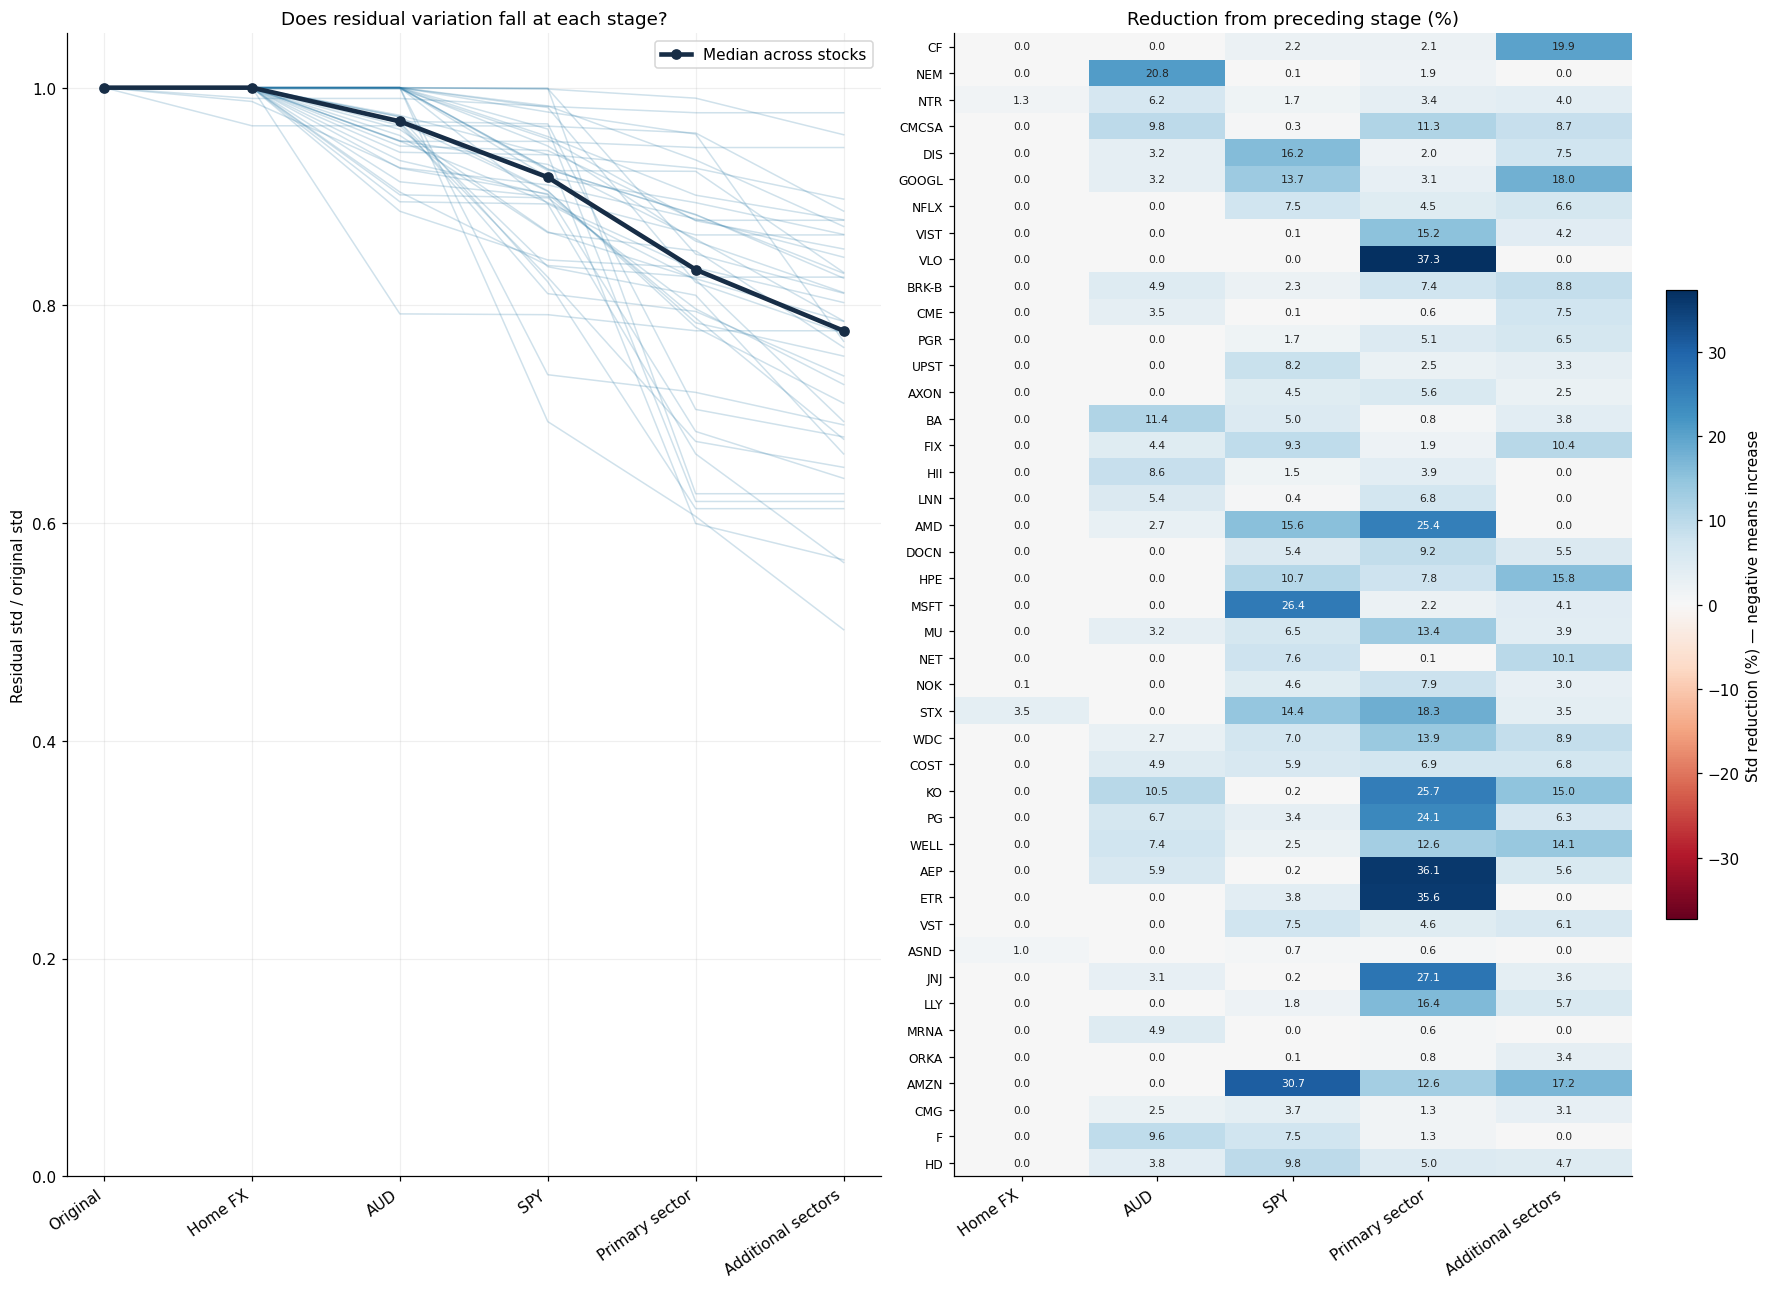

In [ ]:
stage_order = ["Original", "Home FX", "AUD", "SPY", "Primary sector", "Additional sectors"]
progress = (tables["residual_progress"].query("stagger == @plot_stagger")
            .pivot(index="ticker", columns="stage", values="residual_std")
            .reindex(index=plot_order, columns=stage_order))
# A zero starting standard deviation has no defined proportional reduction.
normalized = progress.div(progress["Original"].replace(0, np.nan), axis=0)
previous_std = progress.shift(axis=1)
step_reduction = 100 * (1 - progress.div(previous_std.replace(0, np.nan)))
step_reduction = step_reduction.iloc[:, 1:]
increase_tolerance = 1e-12 + 1e-10 * previous_std.abs()
increases = (progress - previous_std) > increase_tolerance
violations = (progress - previous_std).where(increases).stack().dropna().rename("std_increase")
print(f"Checked {len(progress)} stocks across {len(stage_order) - 1} transitions: "
      f"{len(violations)} increases beyond numerical tolerance.")
if not violations.empty:
    display(violations.to_frame())

fig, axes = plt.subplots(1, 2, figsize=(16, max(9, len(progress) * 0.27)),
                         layout="constrained", gridspec_kw={"width_ratios": [1.2, 1]})
for ticker, row in normalized.iterrows():
    axes[0].plot(range(len(stage_order)), row, color="#2878A5", alpha=0.22, linewidth=1)
axes[0].plot(range(len(stage_order)), normalized.median(), color="#172D46",
             marker="o", linewidth=3, label="Median across stocks")
axes[0].set_xticks(range(len(stage_order)), stage_order, rotation=35, ha="right")
axes[0].set(title="Does residual variation fall at each stage?",
            ylabel="Residual std / original std", ylim=(0, max(1.05, normalized.max().max() * 1.05)))
axes[0].grid(alpha=0.2)
axes[0].legend()

cmap = plt.get_cmap("RdBu").copy()
cmap.set_bad("#DDDDDD")
limit = max(1.0, float(np.nanmax(np.abs(step_reduction.to_numpy()))))
im = axes[1].imshow(step_reduction, cmap=cmap, vmin=-limit, vmax=limit, aspect="auto")
axes[1].set_xticks(range(len(stage_order) - 1), stage_order[1:], rotation=35, ha="right")
axes[1].set_yticks(range(len(progress)), plot_order, fontsize=8)
axes[1].set_title("Reduction from preceding stage (%)")
for row in range(len(progress)):
    for col in range(len(stage_order) - 1):
        value = step_reduction.iloc[row, col]
        if np.isfinite(value):
            axes[1].text(col, row, f"{value:.1f}", ha="center", va="center", fontsize=7,
                         color="white" if abs(value) > limit * 0.6 else "#222222")
fig.colorbar(im, ax=axes[1], shrink=0.55, label="Std reduction (%) — negative means increase")
plt.show()

## Overall factor and residual diagnostics

### Which factors drive each stock?

Rows are grouped by primary sector (shown in parentheses). Red indicates positive exposure; blue indicates negative exposure. Currency and equity panels have separate symmetric color scales so large FX betas do not hide equity exposures. White means zero applied exposure, including skipped or rejected factors; it does not establish that the true exposure is zero.

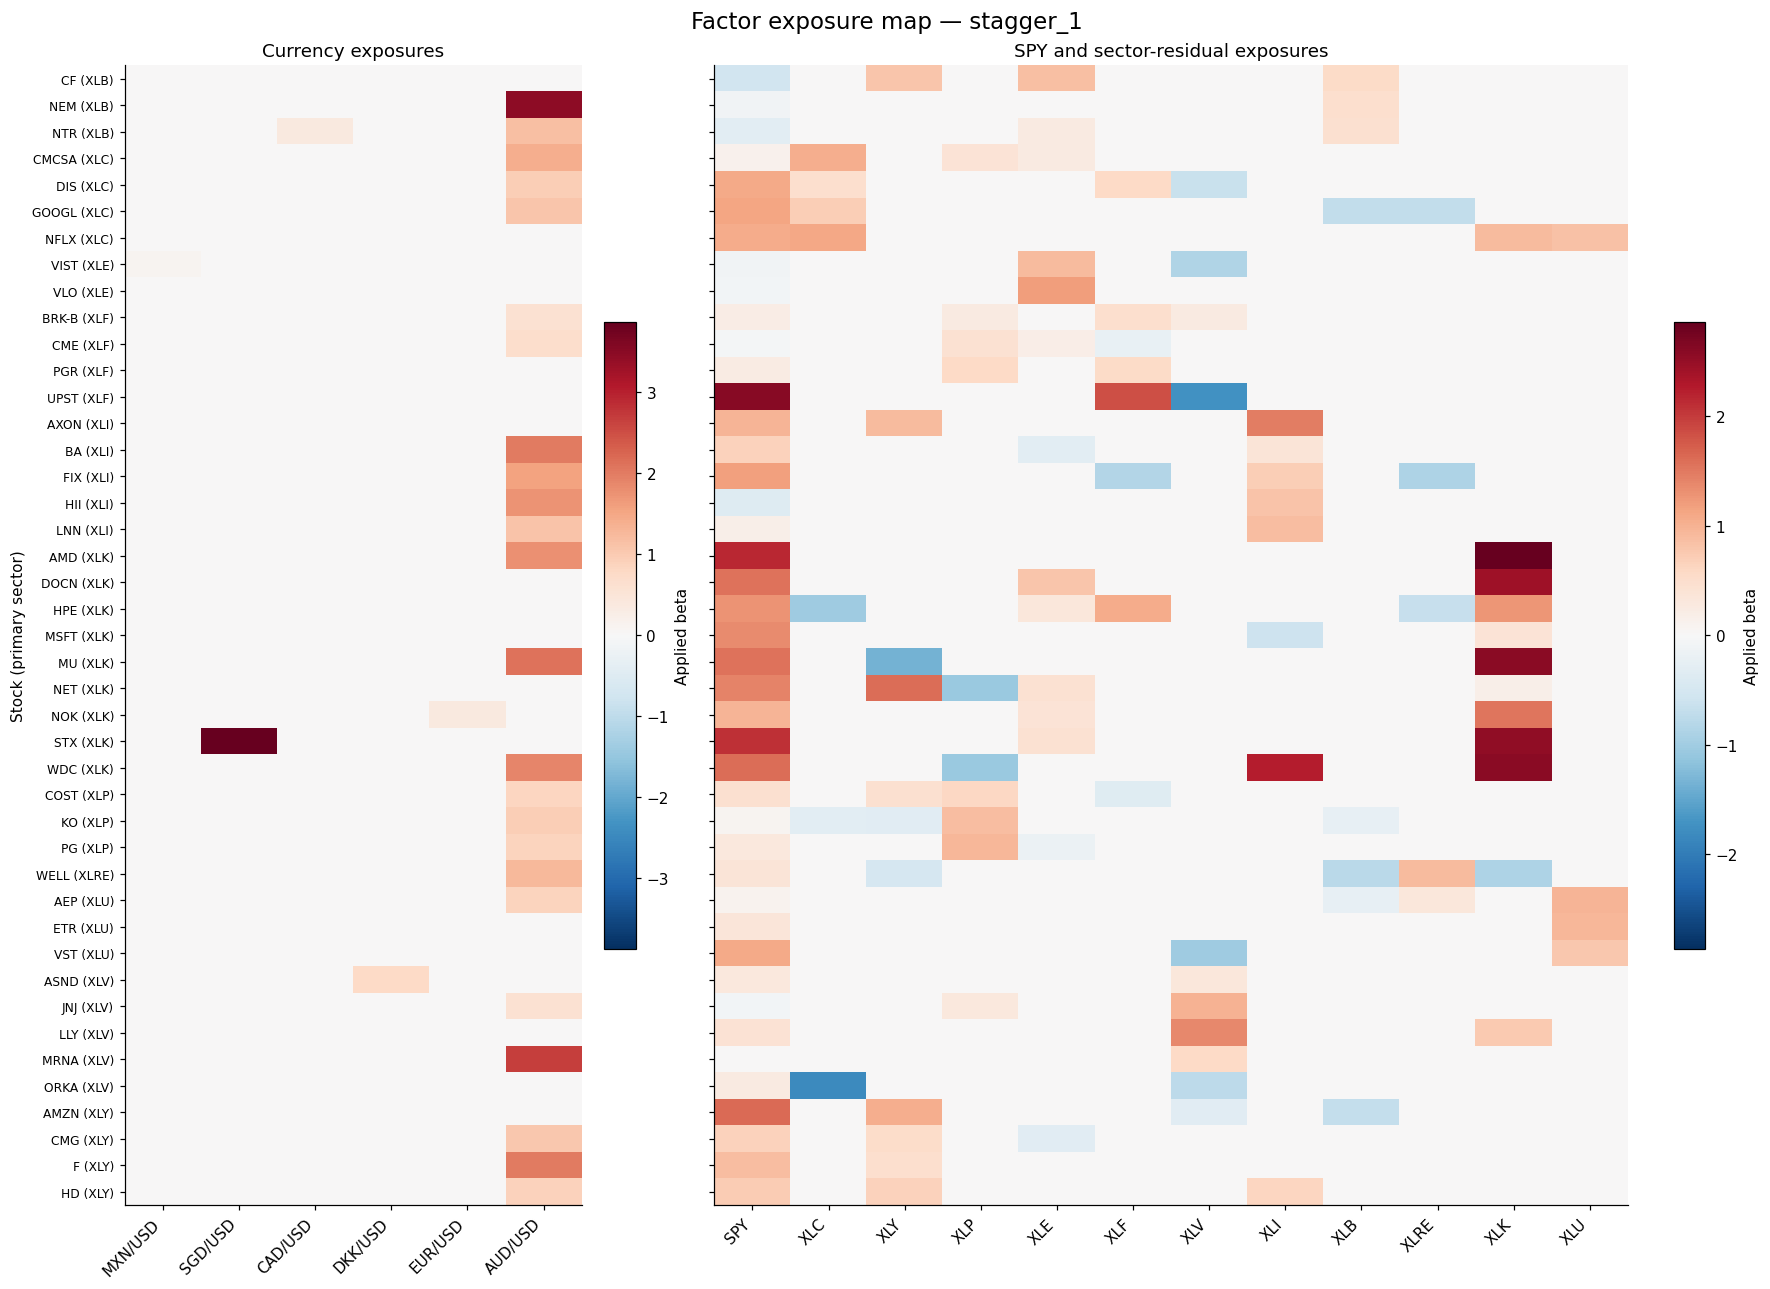

In [ ]:
fx_columns = [c for c in plot_exposures if c.startswith("beta_") and "/USD" in c]
equity_columns = [c for c in plot_exposures if c.startswith("beta_") and "/USD" not in c]
fig, axes = plt.subplots(1, 2, figsize=(16, max(8, len(plot_order) * 0.27)),
                         sharey=True, layout="constrained",
                         gridspec_kw={"width_ratios": [len(fx_columns), len(equity_columns)]})
for ax, columns, title in zip(axes, [fx_columns, equity_columns],
                             ["Currency exposures", "SPY and sector-residual exposures"]):
    values = plot_exposures[columns].to_numpy(dtype=float)
    limit = max(float(np.nanmax(np.abs(values))), 0.01)
    im = ax.imshow(values, cmap="RdBu_r", vmin=-limit, vmax=limit, aspect="auto")
    ax.set_xticks(range(len(columns)), [c.removeprefix("beta_") for c in columns],
                  rotation=45, ha="right")
    ax.set_yticks(range(len(plot_order)), plot_labels, fontsize=8)
    ax.set_title(title)
    fig.colorbar(im, ax=ax, shrink=0.55, label="Applied beta")
axes[0].set_ylabel("Stock (primary sector)")
fig.suptitle(f"Factor exposure map — {plot_stagger}", fontsize=15)
plt.show()

### How much market exposure remains after the currency stages?

SPY betas are estimated after any retained currency stages and before the sector stages. The dashed line marks beta = 1; the solid line marks zero. Negative values indicate an inverse relationship at this stage. This ranking shows estimates, not their statistical significance.

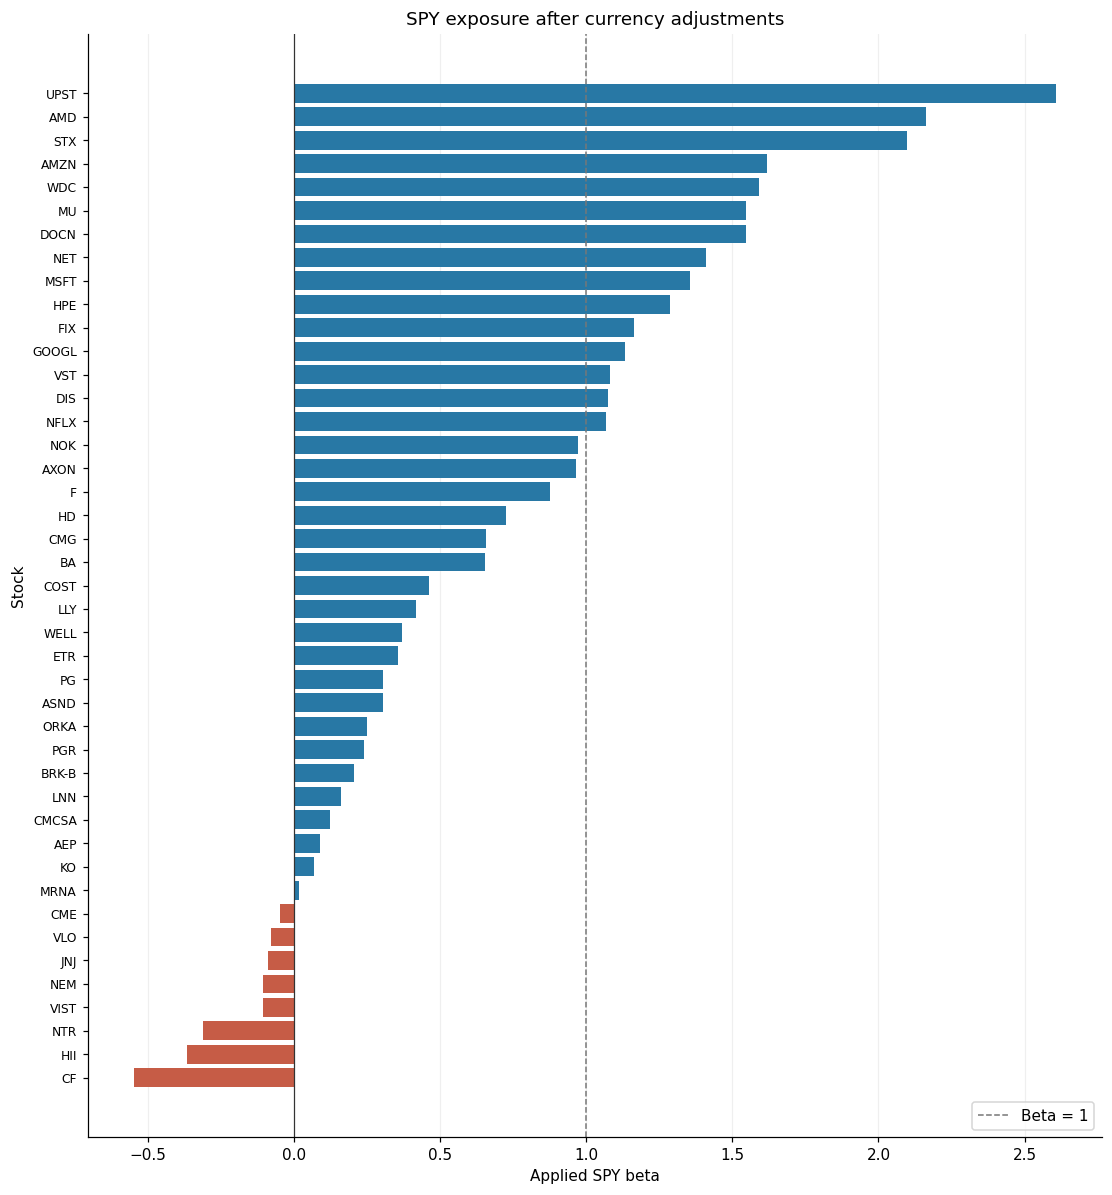

In [ ]:
spy_beta = plot_exposures["beta_SPY"].sort_values()
fig, ax = plt.subplots(figsize=(10, max(7, len(spy_beta) * 0.25)), layout="constrained")
ax.barh(spy_beta.index, spy_beta, color=np.where(spy_beta >= 0, "#2878A5", "#C65C46"))
ax.axvline(0, color="#333333", linewidth=0.8)
ax.axvline(1, color="#777777", linestyle="--", linewidth=1, label="Beta = 1")
ax.set(title="SPY exposure after currency adjustments", xlabel="Applied SPY beta", ylabel="Stock")
ax.tick_params(axis="y", labelsize=8)
ax.legend(loc="lower right")
ax.grid(axis="x", alpha=0.2)
ax.set_axisbelow(True)
plt.show()

### Which stocks pass the AUD selection rule?

The bars show the **tested** AUD t-statistic, including rejected estimates. AUD is retained only when |t| > 2; the dashed lines show the strict cutoff. For foreign stocks this test follows the home-currency regression; for US stocks it uses the original weighted return. Classical OLS t-statistics are not adjusted for multiple testing.

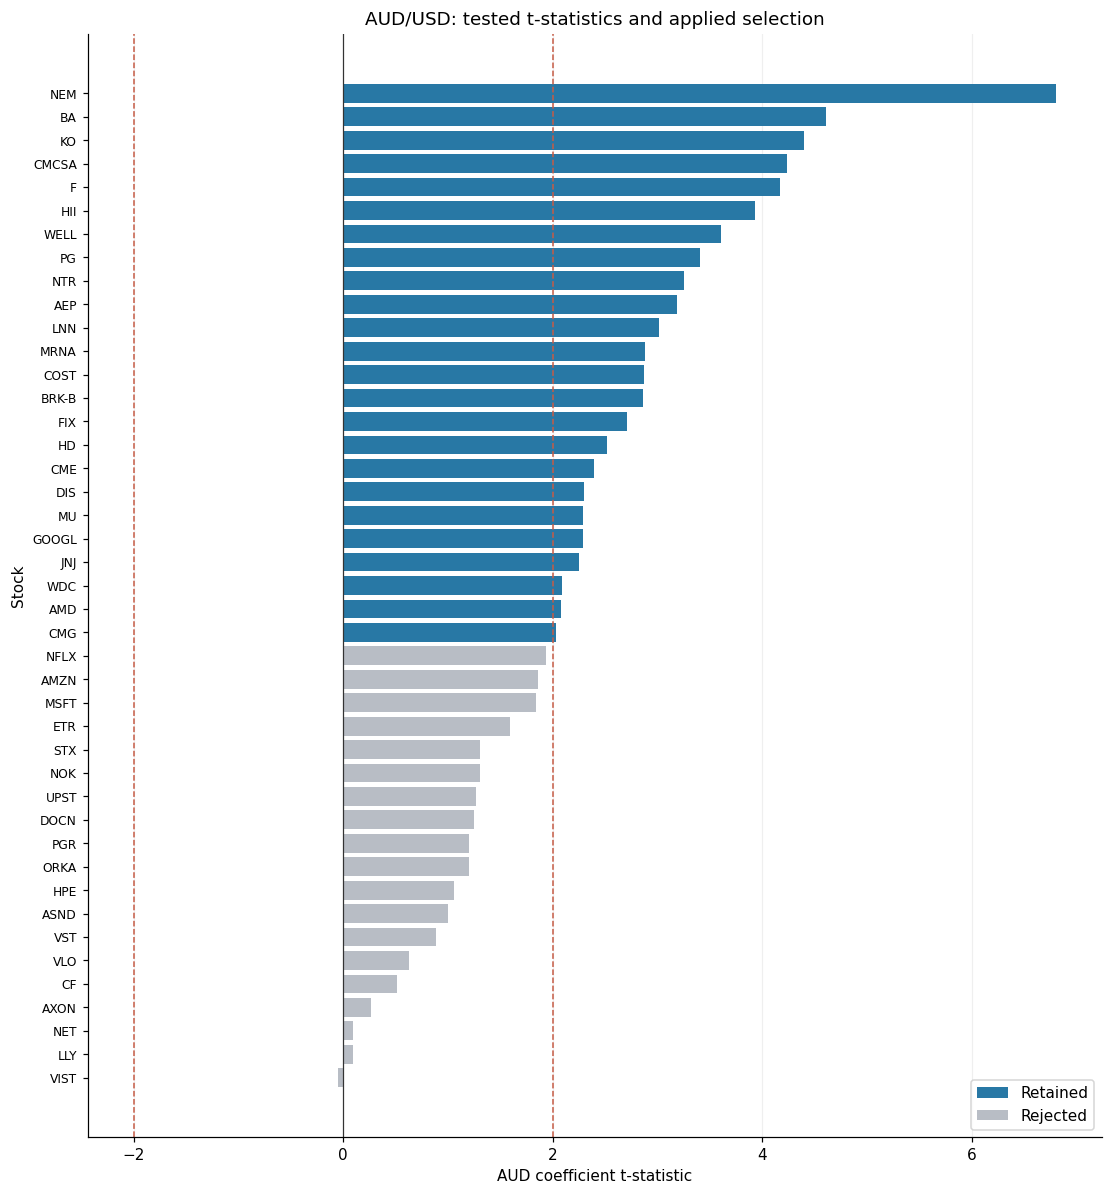

In [ ]:
aud = plot_stages.loc[plot_stages["factor"].eq("AUD/USD")].sort_values("t_stat")
fig, ax = plt.subplots(figsize=(10, max(7, len(aud) * 0.25)), layout="constrained")
for retained, color, label in [(True, "#2878A5", "Retained"), (False, "#B8BDC5", "Rejected")]:
    subset = aud.loc[aud["retained"].eq(retained)]
    positions = np.flatnonzero(aud["retained"].eq(retained).to_numpy())
    ax.barh(positions, subset["t_stat"], color=color, label=label)
ax.set_yticks(range(len(aud)), aud["ticker"], fontsize=8)
for cutoff in [-2, 2]:
    ax.axvline(cutoff, color="#C65C46", linestyle="--", linewidth=1)
ax.axvline(0, color="#333333", linewidth=0.8)
ax.set(title="AUD/USD: tested t-statistics and applied selection", xlabel="AUD coefficient t-statistic",
       ylabel="Stock")
ax.legend()
ax.grid(axis="x", alpha=0.2)
ax.set_axisbelow(True)
plt.show()

### Where is the largest remaining variation?

Stocks are ranked by their final residual sample standard deviation (ddof = 1). Labels report the number of observations used for each stock, since shorter listing histories can make comparisons less reliable. Values are neither annualized nor unweighted stock volatility.

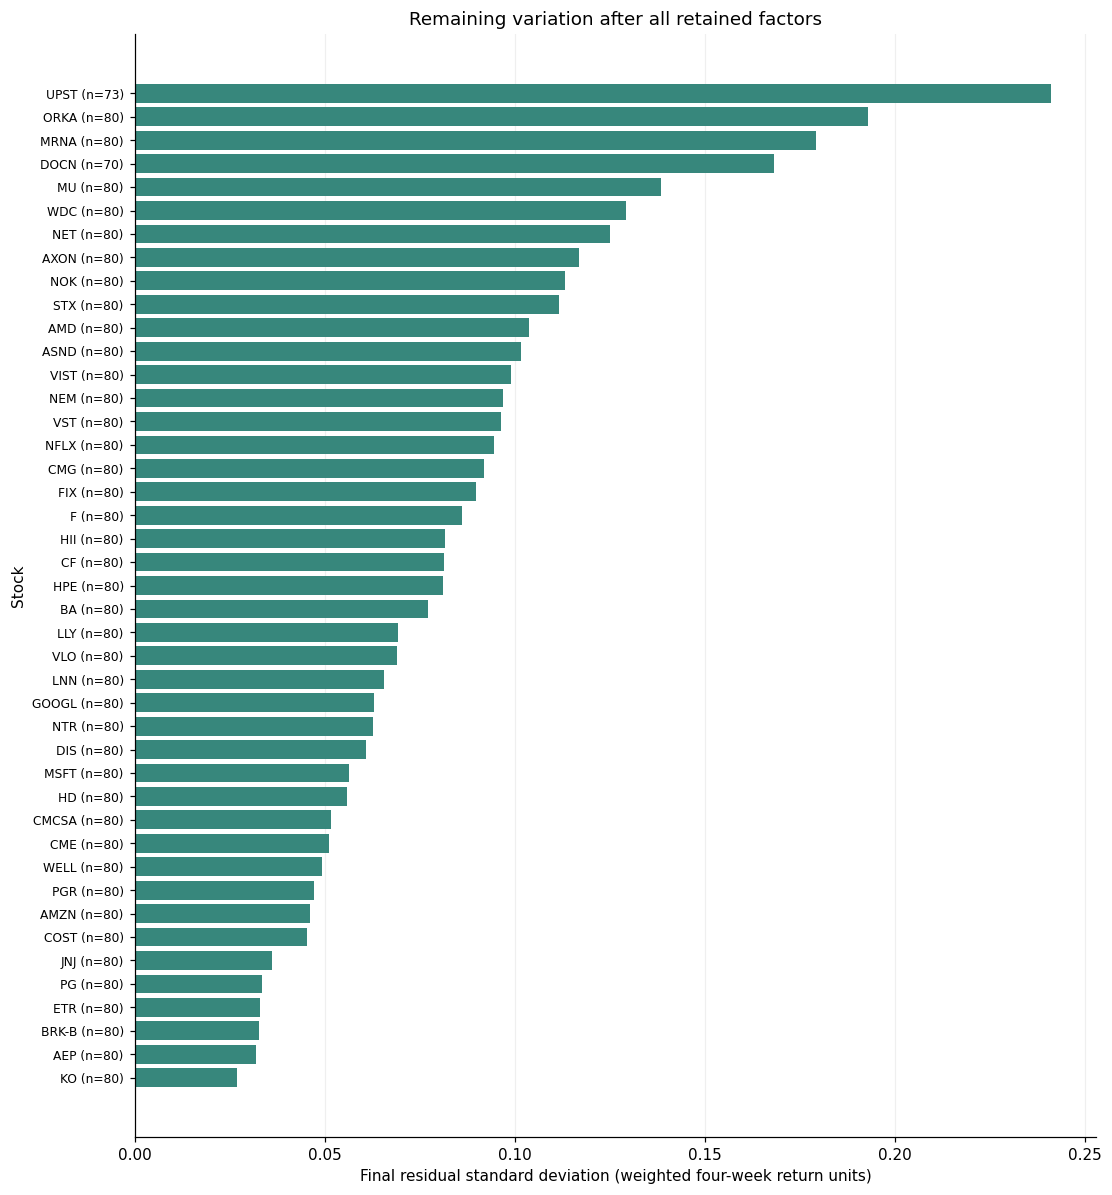

In [ ]:
risk = plot_diagnostics.sort_values("residual_std")
fig, ax = plt.subplots(figsize=(10, max(7, len(risk) * 0.25)), layout="constrained")
ax.barh(range(len(risk)), risk["residual_std"], color="#37877C")
ax.set_yticks(range(len(risk)),
              [f"{ticker} (n={int(n)})" for ticker, n in risk["observations"].items()], fontsize=8)
ax.set(title="Remaining variation after all retained factors",
       xlabel="Final residual standard deviation (weighted four-week return units)", ylabel="Stock")
ax.grid(axis="x", alpha=0.2)
ax.set_axisbelow(True)
plt.show()

### Do stocks still move together after the factor stages?

This correlation map uses only dates with final residuals for **every** stock, giving every pair the same sample. The title reports that sample size; no missing returns are filled. Stocks follow the same sector grouping as the exposure map. Strong off-diagonal patterns suggest remaining shared variation, not proof of an omitted causal factor or independent residuals. Constant residual series yield undefined (gray) correlations.

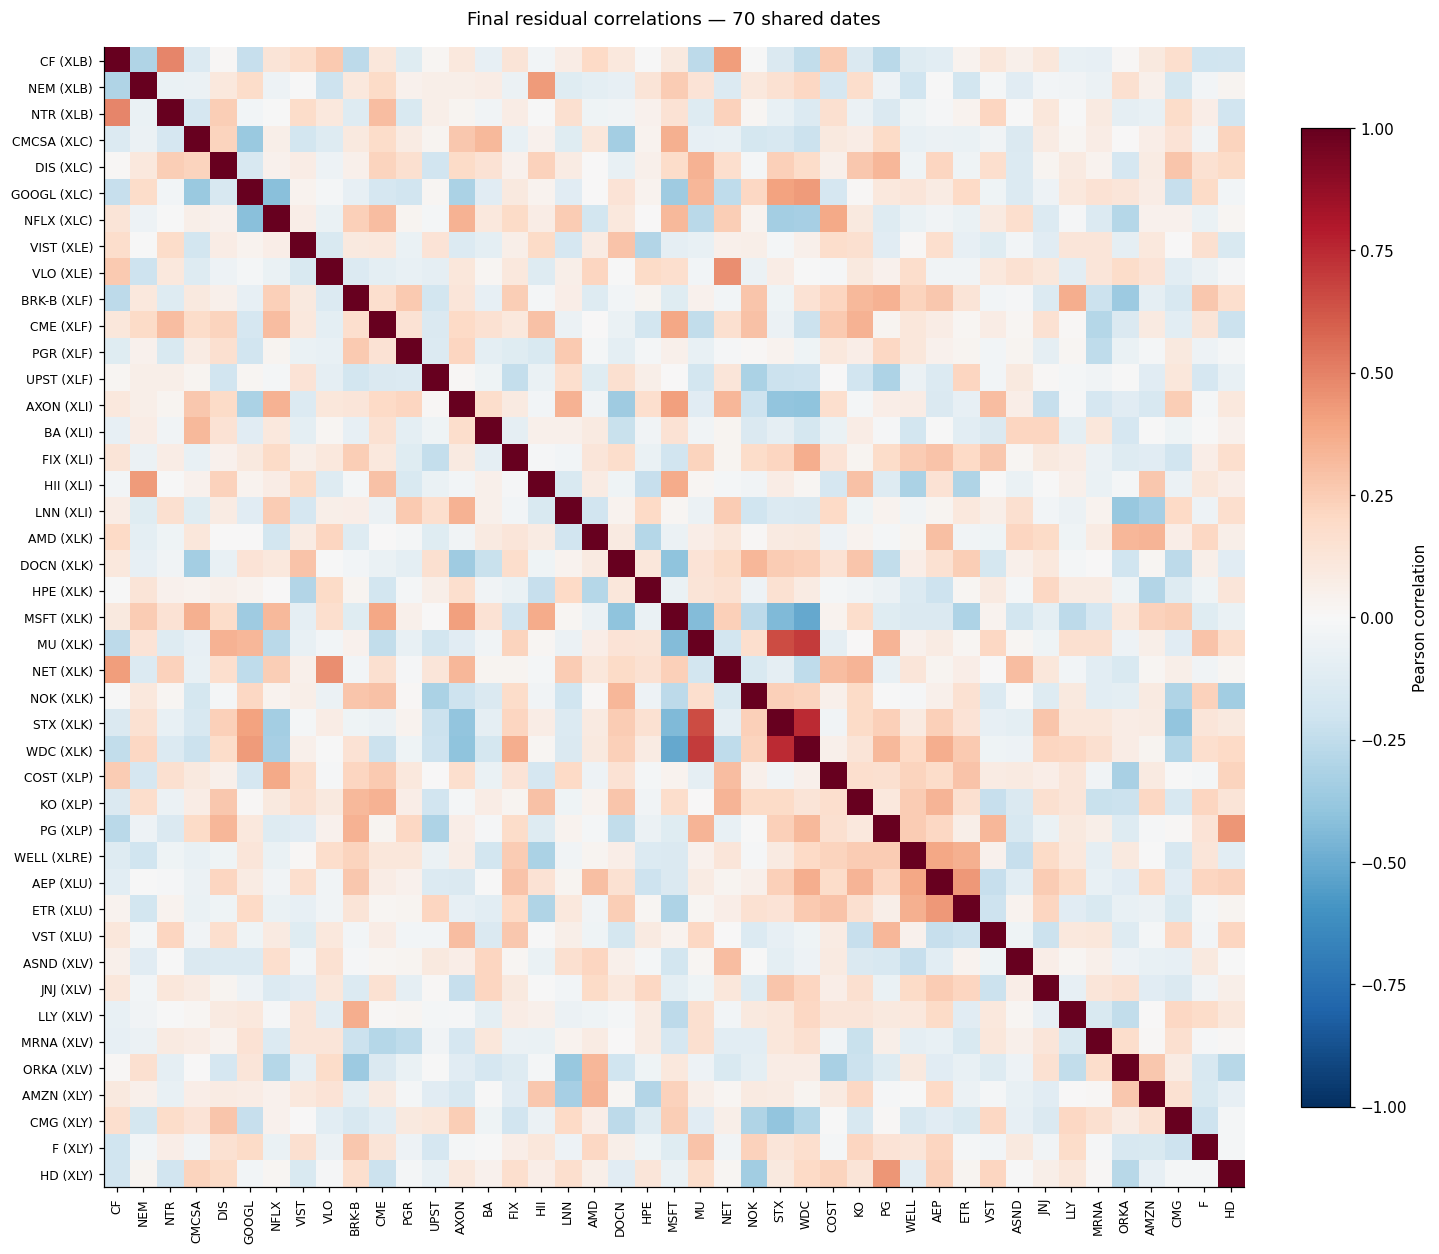

In [ ]:
common_residuals = plot_residuals.dropna(how="any")
if len(common_residuals) < 3:
    print("Too few shared dates to plot residual correlations (need at least 3).")
else:
    correlation = common_residuals.corr()
    fig, ax = plt.subplots(figsize=(13, 12), layout="constrained")
    cmap = plt.get_cmap("RdBu_r").copy()
    cmap.set_bad("#DDDDDD")
    im = ax.imshow(correlation, vmin=-1, vmax=1, cmap=cmap)
    ax.set_xticks(range(len(plot_order)), plot_order, rotation=90, fontsize=8)
    ax.set_yticks(range(len(plot_order)), plot_labels, fontsize=8)
    ax.set_title(f"Final residual correlations — {len(common_residuals)} shared dates", pad=15)
    fig.colorbar(im, ax=ax, shrink=0.75, label="Pearson correlation")
    plt.show()

## Full output tables

In [ ]:
tables["diagnostics"]

,stagger,ticker,currency,primary_sector,observations,start,end,residual_std,additional_sectors,reconstruction_error
0,stagger_1,VST,USD,XLU,80,2020-07-20,2026-08-10,0.096511,XLV,2.775558e-17
1,stagger_1,VIST,MXN,XLE,80,2020-07-20,2026-08-10,0.098969,XLV,5.551115e-17
2,stagger_1,AEP,USD,XLU,80,2020-07-20,2026-08-10,0.031844,"XLRE,XLB",1.387779e-17
3,stagger_1,ETR,USD,XLU,80,2020-07-20,2026-08-10,0.032963,,1.387779e-17
4,stagger_1,DIS,USD,XLC,80,2020-07-20,2026-08-10,0.061002,"XLV,XLF",2.775558e-17
5,stagger_1,CMG,USD,XLY,80,2020-07-20,2026-08-10,0.091903,XLE,5.551115e-17
6,stagger_1,AMZN,USD,XLY,80,2020-07-20,2026-08-10,0.046075,"XLB,XLV",2.775558e-17
7,stagger_1,FIX,USD,XLI,80,2020-07-20,2026-08-10,0.089743,"XLRE,XLF",4.163336e-17
8,stagger_1,STX,SGD,XLK,80,2020-07-20,2026-08-10,0.111769,XLE,5.551115e-17
9,stagger_1,VLO,USD,XLE,80,2020-07-20,2026-08-10,0.068946,,2.775558e-17


In [ ]:
tables["factor_exposures"]

,stagger,ticker,beta_MXN/USD,beta_SGD/USD,beta_CAD/USD,beta_DKK/USD,beta_EUR/USD,beta_AUD/USD,beta_SPY,beta_XLC,...,beta_XLP,beta_XLE,beta_XLF,beta_XLV,beta_XLI,beta_XLB,beta_XLRE,beta_XLK,beta_XLU,alpha_total
0,stagger_1,VST,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.080770,0.000000,...,0.000000,0.000000,0.000000,-1.006887,0.000000,0.000000,0.000000,0.000000,0.773940,0.013536
1,stagger_1,VIST,0.095817,0.000000,0.000000,0.000000,0.000000,0.000000,-0.105156,0.000000,...,0.000000,0.901289,0.000000,-0.850885,0.000000,0.000000,0.000000,0.000000,0.000000,0.036857
2,stagger_1,AEP,0.000000,0.000000,0.000000,0.000000,0.000000,0.867205,0.090570,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,-0.227449,0.313767,0.000000,0.977930,0.007645
3,stagger_1,ETR,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.355563,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.942475,0.010415
4,stagger_1,DIS,0.000000,0.000000,0.000000,0.000000,0.000000,0.947990,1.073992,0.473726,...,0.000000,0.000000,0.558949,-0.643158,0.000000,0.000000,0.000000,0.000000,0.000000,-0.014955
5,stagger_1,CMG,0.000000,0.000000,0.000000,0.000000,0.000000,1.042484,0.658024,0.000000,...,0.000000,-0.324756,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-0.008362
6,stagger_1,AMZN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.619583,0.000000,...,0.000000,0.000000,0.000000,-0.314798,0.000000,-0.677576,0.000000,0.000000,0.000000,-0.010994
7,stagger_1,FIX,0.000000,0.000000,0.000000,0.000000,0.000000,1.569809,1.164377,0.000000,...,0.000000,0.000000,-0.831899,0.000000,0.693957,0.000000,-0.890692,0.000000,0.000000,0.035471
8,stagger_1,STX,0.000000,3.872352,0.000000,0.000000,0.000000,0.000000,2.096842,0.000000,...,0.000000,0.424888,0.000000,0.000000,0.000000,0.000000,0.000000,2.529228,0.000000,0.019837
9,stagger_1,VLO,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-0.076133,0.000000,...,0.000000,1.193654,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.029405


In [ ]:
tables["stage_coefficients"].query("factor == 'AUD/USD'")

,stagger,ticker,step,factor,alpha,beta,t_stat,p_value,retained,applied_beta,observations,r_squared
0,stagger_1,VST,3,AUD/USD,0.027330,0.529051,0.888333,3.770931e-01,False,0.000000,80,0.010016
5,stagger_1,VIST,2,AUD/USD,0.000022,-0.030131,-0.048017,9.618253e-01,False,0.000000,80,0.000030
9,stagger_1,AEP,3,AUD/USD,0.008834,0.867205,3.186870,2.069464e-03,True,0.867205,80,0.115206
14,stagger_1,ETR,3,AUD/USD,0.014769,0.428101,1.590126,1.158516e-01,False,0.000000,80,0.031399
17,stagger_1,DIS,3,AUD/USD,-0.000865,0.947990,2.294841,2.443133e-02,True,0.947990,80,0.063246
22,stagger_1,CMG,3,AUD/USD,0.000270,1.042484,2.030972,4.566508e-02,True,1.042484,80,0.050227
26,stagger_1,AMZN,3,AUD/USD,0.009629,0.858462,1.858281,6.690202e-02,False,0.000000,80,0.042395
31,stagger_1,FIX,3,AUD/USD,0.050746,1.569809,2.708158,8.311667e-03,True,1.569809,80,0.085946
37,stagger_1,STX,2,AUD/USD,-0.000801,1.103577,1.309511,1.942054e-01,False,0.000000,80,0.021512
41,stagger_1,VLO,3,AUD/USD,0.028148,0.356318,0.631491,5.295657e-01,False,0.000000,80,0.005087


In [ ]:
residuals["stagger_1"]

,VST,VIST,AEP,ETR,DIS,CMG,AMZN,FIX,STX,VLO,...,LLY,WELL,NOK,MSFT,GOOGL,COST,HD,KO,JNJ,BRK-B
date,,,,,,,,,,,,,,,,,,,,,
2020-07-20,-0.031984,0.073733,0.022194,0.009349,0.005347,0.009353,0.031220,-0.071677,-0.016930,-0.013472,...,-0.051433,-0.018266,-0.003283,-0.010440,0.003988,-0.007584,0.001521,0.020629,-0.012049,0.013950
2020-08-17,-0.029686,-0.111540,-0.052691,-0.019486,0.023536,0.018127,-0.018780,0.022210,-0.172231,-0.028205,...,-0.070844,0.026777,0.028040,-0.007704,-0.048510,-0.013923,0.001263,-0.035653,0.007244,0.029123
2020-09-14,-0.023774,-0.124422,-0.003018,-0.015797,0.017256,-0.035877,-0.012595,-0.024554,0.089272,-0.001079,...,0.016206,0.001316,-0.061681,0.007987,-0.003780,-0.021584,-0.029693,0.038190,-0.025178,0.011302
2020-10-12,-0.047516,0.001156,0.048673,0.003530,0.003492,0.036977,0.005000,-0.018801,-0.032284,-0.057443,...,-0.067403,-0.020127,-0.023069,0.015210,0.014172,0.049722,0.023081,-0.011274,-0.008499,-0.016681
2020-11-09,-0.005868,-0.034675,-0.035361,-0.006474,0.018500,-0.032903,-0.020316,-0.108054,0.003051,0.047642,...,-0.036897,0.046972,-0.038687,-0.010116,0.036724,-0.014650,-0.038294,0.016244,-0.024979,0.004029
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-04-20,-0.159219,-0.039745,0.029633,0.030572,-0.078335,-0.038288,0.125387,0.017181,0.100917,0.025839,...,-0.025822,-0.047529,0.193083,-0.017824,0.076428,-0.065957,-0.066705,-0.049799,-0.025290,-0.026621
2026-05-18,-0.093305,0.033692,0.003016,0.012223,0.018131,-0.042761,-0.076241,-0.033632,0.123728,-0.021395,...,0.144098,0.009613,0.394607,-0.181063,0.036927,0.006134,-0.068785,0.017410,0.011113,0.046967
2026-06-15,0.065147,-0.034910,0.012205,-0.006461,0.061496,-0.029706,-0.081869,0.080291,0.324396,0.116050,...,-0.024233,0.064295,-0.286810,-0.150689,0.030668,-0.063875,0.115764,-0.011425,-0.007319,0.008216
